In [1]:
import pandas as pd
import glob
import os

In [2]:
pd.options.display.float_format = '{:.0f}'.format

In [4]:
import os
print(os.getcwd())

c:\Users\cute3\OneDrive\Desktop\pro\final_project\sungju


In [5]:
file_path = "../Data/성남시_공시지가_통합__202604221844.csv"

print(os.path.exists(file_path))

df_price = pd.read_csv(file_path, encoding="utf-8-sig")

df_price.head(2)

True


,고유번호,법정동코드,법정동명,특수지구분명,지번,기준연도,기준월,공시지가,표준지여부,기준년월,건물용도분류명
0,4113511700100760002,4113511700,경기도 성남시 분당구 석운동,일반,76-2,2023,1,1014000,N,2023-01-01,상업용
1,4113511700100780006,4113511700,경기도 성남시 분당구 석운동,일반,78-6,2023,1,1361000,N,2023-01-01,상업용


In [4]:
df_price.info()

<class 'pandas.DataFrame'>
RangeIndex: 15557 entries, 0 to 15556
Data columns (total 11 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   고유번호     15557 non-null  int64
 1   법정동코드    15557 non-null  int64
 2   법정동명     15557 non-null  str  
 3   특수지구분명   15557 non-null  str  
 4   지번       15557 non-null  str  
 5   기준연도     15557 non-null  int64
 6   기준월      15557 non-null  int64
 7   공시지가     15557 non-null  int64
 8   표준지여부    15557 non-null  str  
 9   기준년월     15557 non-null  str  
 10  건물용도분류명  15557 non-null  str  
dtypes: int64(5), str(6)
memory usage: 2.3 MB


In [ ]:
# 중복 행 없음
df_price[df_price.duplicated(subset=['고유번호', '법정동코드', '법정동명', '특수지구분명', '지번', '기준연도', '기준월', '공시지가', '표준지여부', '기준년월', '건물용도분류명'], keep=False)]

,고유번호,법정동코드,법정동명,특수지구분명,지번,기준연도,기준월,공시지가,표준지여부,기준년월,건물용도분류명


In [ ]:
# 분류명도 상업용 맞음
df_price['건물용도분류명'].value_counts()

건물용도분류명
상업용    15557
Name: count, dtype: int64

In [ ]:
# 산???
df_price['특수지구분명'].value_counts()

특수지구분명
일반    15542
산        15
Name: count, dtype: int64

In [ ]:
df_price[df_price['특수지구분명'] == '산']

,고유번호,법정동코드,법정동명,특수지구분명,지번,기준연도,기준월,공시지가,표준지여부,기준년월,건물용도분류명


- 경기도 성남시 분당구 동원동	67-8	= 산지

- 경기도 성남시 수정구 창곡동	116-4	 = 산지

- 경기도 성남시 수정구 수진동 41-3 = 공원

- 경기도 성남시 수정구 상적동	52-3 = 산 안에 있는 관리사무소? 느낌으로 추정

- 경기도 성남시 수정구 단대동 164-3 = 지도상 주택 + 식당 = 토지계획에는 임야임

   -> 분석 대상과 거리가 멀다고 생각하여 모두 삭제

In [5]:
df_price = df_price[df_price['특수지구분명'] != '산']

In [ ]:
# 법정동명의 구 별 개수
df_price['구'] = df_price['법정동명'].str.extract(r'(분당구|수정구|중원구)')


print(df_price['구'].value_counts())

구
수정구    6429
중원구    4857
분당구    4256
Name: count, dtype: int64


In [ ]:
# 기준연도 2023~2025 맞는지 확인
print(sorted(df_price['기준연도'].unique()))

[np.int64(2023), np.int64(2024), np.int64(2025)]


In [ ]:
#기준월에 1,7이 있는지 확인 -> 공시지가는 1년에 2번 체크함
print(sorted(df_price['기준월'].unique()))

[np.int64(1), np.int64(7)]


In [12]:
print(sorted(df_price['기준년월'].unique()))

['2023-01-01', '2023-07-01', '2024-01-01', '2024-07-01', '2025-01-01', '2025-07-01']


## 공시지가
최솟값: 1m²당 2만3,500원(23,500원) <br>
최댓값: 1m²당 3,004만원(30,040,000원)

In [16]:
df_price['공시지가'].describe()

count      15557
mean     5108037
std      2761173
min        23500
25%      3321000
50%      4507000
75%      6017000
max     30040000
Name: 공시지가, dtype: float64

In [ ]:
df_price['공시지가'].quantile([0.01, 0.99])

0     604412
1   14024400
Name: 공시지가, dtype: float64

In [21]:
import numpy as np
q_1 = np.percentile(df_price['공시지가'], q=25)
q_3 = np.percentile(df_price['공시지가'], q=75)
iqr = q_3 - q_1

lower = q_1 - 1.5 * iqr
upper = q_3 + 1.5 * iqr

outliers = df_price[
    (df_price['공시지가'] < lower) |
    (df_price['공시지가'] > upper)
]

outliers

,고유번호,법정동코드,법정동명,특수지구분명,지번,기준연도,기준월,공시지가,표준지여부,기준년월,건물용도분류명
108,4113511100101510000,4113511100,경기도 성남시 분당구 금곡동,일반,151,2023,1,10910000,Y,2023-01-01,상업용
109,4113511100101530000,4113511100,경기도 성남시 분당구 금곡동,일반,153,2023,1,10910000,N,2023-01-01,상업용
110,4113511100101550000,4113511100,경기도 성남시 분당구 금곡동,일반,155,2023,1,10910000,N,2023-01-01,상업용
111,4113511100101580000,4113511100,경기도 성남시 분당구 금곡동,일반,158,2023,1,11360000,N,2023-01-01,상업용
112,4113511100101590000,4113511100,경기도 성남시 분당구 금곡동,일반,159,2023,1,11360000,N,2023-01-01,상업용
...,...,...,...,...,...,...,...,...,...,...,...
15262,4113313200100950000,4113313200,경기도 성남시 중원구 중앙동,일반,95,2025,1,10780000,N,2025-01-01,상업용
15282,4113313200103070000,4113313200,경기도 성남시 중원구 중앙동,일반,307,2025,1,11550000,N,2025-01-01,상업용
15285,4113313200103350000,4113313200,경기도 성남시 중원구 중앙동,일반,335,2025,1,11200000,N,2025-01-01,상업용
15289,4113313200104210000,4113313200,경기도 성남시 중원구 중앙동,일반,421,2025,1,15100000,N,2025-01-01,상업용


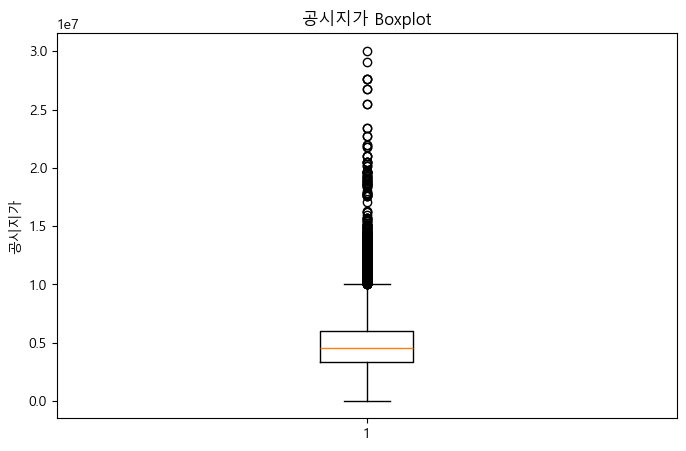

In [23]:
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'Malgun Gothic'  # 윈도우 한글 폰트
plt.rcParams['axes.unicode_minus'] = False     # 마이너스 깨짐 방지

plt.figure(figsize=(8,5))
plt.boxplot(df_price['공시지가'].dropna())
plt.title('공시지가 Boxplot')
plt.ylabel('공시지가')
plt.show()

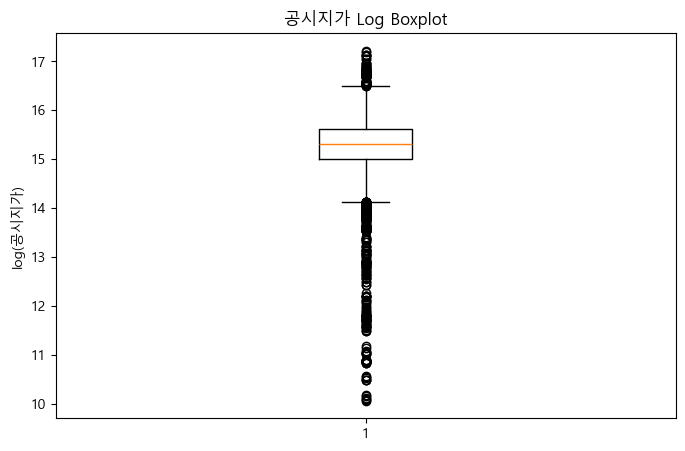

In [24]:
import numpy as np
import matplotlib.pyplot as plt

df_price['공시지가_log'] = np.log1p(df_price['공시지가'])

plt.figure(figsize=(8,5))
plt.boxplot(df_price['공시지가_log'].dropna())
plt.title('공시지가 Log Boxplot')
plt.ylabel('log(공시지가)')
plt.show()